## 1. Print Dataset Structure

In [1]:
import os

def count_images(path):
    return len(os.listdir(path))

print("Dataset overview loaded from YAML:")
print(open("dataset.yaml").read())
print("")
train = count_images("dataset/train/images")
val = count_images("dataset/val/images")
test = count_images("dataset/test/images")

print("Train:", train)
print("Val:", val)
print("Test:", test)

Dataset overview loaded from YAML:
path: ./dataset

train: train/images
val: val/images
test: test/images

nc: 3

names:
  0: crack
  1: potholes
  2: wall_peeling

Train: 324
Val: 108
Test: 109


In [5]:
from ultralytics import YOLO
model = YOLO("yolo26s.pt")
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 22.8 GFLOPs


(260, 10009784, 0, 22.838476800000002)

In [6]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
 

## 2. IoU and Evaluation Functions

In [2]:
from ultralytics import YOLO
import cv2
import glob
import os
import numpy as np

def iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0


def evaluate(model_path, data_yaml, run_name):

    model = YOLO(model_path)

    metrics = model.val(
        data=data_yaml,
        split="test",
        plots=True
    )

    image_paths = glob.glob("dataset/test/images/*")

    all_ious = []

    for img_path in image_paths:

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w = img.shape[:2]

        label_path = (
            img_path
            .replace("images", "labels")
            .rsplit(".", 1)[0] + ".txt"
        )

        gt_boxes = []

        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    cls, xc, yc, bw, bh = map(float, line.split())

                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    x2 = (xc + bw/2) * w
                    y2 = (yc + bh/2) * h

                    gt_boxes.append([x1, y1, x2, y2])

        pred = model.predict(
            img_path,
            conf=0.25,
            verbose=False
        )[0]

        pred_boxes = pred.boxes.xyxy.cpu().numpy()

        for gt_box in gt_boxes:

            best_iou = 0

            for pred_box in pred_boxes:

                current_iou = iou(gt_box, pred_box)

                if current_iou > best_iou:
                    best_iou = current_iou

            all_ious.append(best_iou)

    mean_iou = np.mean(all_ious) if all_ious else 0

    summary = {
        "Run": run_name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Mean IoU": mean_iou
    }

    return model, summary, metrics

## 3. Baseline Training

model = YOLO("yolov8s.pt")

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="road_damage",
    name="baseline"
)

baseline_model, baseline_summary, baseline_metrics = evaluate(
    "runs/detect/road_damage/baseline/weights/best.pt",
    "dataset.yaml",
    "baseline"
)

## 4. Iterative Training

In [4]:
from ultralytics import YOLO
import time

runs = [
    # Freeze backbone only (0–10): keeps pretrained feature extractor fixed
    ("frozen_backbone", 11),

    # Freeze backbone + part of neck (0–19): partial fine-tuning
    ("partial_freeze_neck", 20),

    # No freezing (0–23): full fine-tuning
    ("unfrozen", None)
]

results = []

for name, freeze in runs:

    print(f"\n===== Training {name} =====\n")

    model = YOLO("yolo26s.pt")

    start_time = time.time()

    train_args = {
        "data": "dataset.yaml",

        "epochs": 300,
        # long training with early stopping for stability
        "patience": 50,

        "imgsz": 640,
        "batch": 16,

        "optimizer": "AdamW",
        "lr0": 0.0015,   # recommended LR for YOLO fine-tuning
        "lrf": 0.01,
        "warmup_epochs": 3,
        "warmup_bias_lr": 0.05,
        "weight_decay": 1e-4,

        # augmentation for robustness
        "hsv_h": 0.015,
        "hsv_s": 0.7,
        "hsv_v": 0.4,
        "fliplr": 0.5,
        "flipud": 0.1,
        "scale": 0.5,
        "mosaic": 1.0,
        "copy_paste": 0.3,
        "degrees": 10.0,
        "translate": 0.1,

        "workers": 16,
        "save": True,
        "plots": True,
        "amp": True,
        "device": 0,

        "project": "road_damage",
        "name": name,
        "exist_ok": True
    }

    if freeze is not None:
        train_args["freeze"] = freeze

    model.train(**train_args)

    end_time = time.time()
    duration = end_time - start_time

    print(f"\n Training time: {duration/60:.2f} minutes")

    model_path = f"runs/detect/road_damage/{name}/weights/best.pt"

    _, summary, _ = evaluate(
        model_path,
        "dataset.yaml",
        name
    )

    summary["Training Time (min)"] = duration / 60
    results.append(summary)


===== Training freezemost =====

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=20, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=freezemost, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 52.3±24.0 MB/s, size: 72.0 KB)
val: Scanning /home/achin/COS40007-Group/jenny/dataset/val/labels.cache... 108 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 108/108 5.1Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/jenny/runs/detect/road_damage/freezemost/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/achin/COS40007-Group/jenny/runs/detect/road_damage/freezemost
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50       1.6G      1.741      15.23    0.02123         16        640: 100% ━━━━━━━━━━━━ 20/20 1.5it/s 13.1s<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0s/it 4.1s0.3ss
                   all        108        127     0.0901     0.0448     0.0342     0.0223

      Epoch  

...

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/jenny/runs/detect/road_damage/unfreeze/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/achin/COS40007-Group/jenny/runs/detect/road_damage/unfreeze
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50      4.67G      1.593      15.76    0.02003         16        640: 100% ━━━━━━━━━━━━ 20/20 5.5it/s 3.6s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 11.0it/s 0.4s.2s
                   all        108        127     0.0348     0.0658     0.0116    0.00452

      Epoch    GPU_m

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      41/50      5.21G      1.152     0.9373    0.01827         16        640: 100% ━━━━━━━━━━━━ 20/20 6.3it/s 3.2s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 13.3it/s 0.3s.6s
                   all        108        127      0.778      0.644      0.733      0.395

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      42/50      5.21G      1.169     0.8836    0.01768         16        640: 100% ━━━━━━━━━━━━ 20/20 9.4it/s 2.1s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 13.7it/s 0.3s.6s
                   all        108        127      0.795      0.589      0.712      0.399

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      43/50      5.21G      1.096     0.8589    0.01717         16        640: 100% ━━━

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.1it/s 1.4s0.1s
                   all        108        145      0.859      0.659      0.742      0.474
                 crack         30         41      0.854      0.572      0.641      0.388
              potholes         30         56        0.9      0.821      0.863      0.617
          wall_peeling         30         48      0.823      0.583      0.722      0.418
Speed: 1.0ms preprocess, 2.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/achin/COS40007-Group/jenny/runs/detect/val-3


## 5. Compare Performance

In [5]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df.sort_values(
    by="mAP50-95",
    ascending=False
)

,Run,Precision,Recall,mAP50,mAP50-95,Mean IoU
2,unfreeze,0.859065,0.658940,0.741862,0.474251,0.592306
1,freezehalf,0.874401,0.638905,0.743292,0.472702,0.584352
0,freezemost,0.730234,0.563937,0.649123,0.384030,0.460892


## Plot Loss and Metrics Curves

In [7]:
def plot_curves(csv_path, title):

    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(1, 2, figsize=(14,5))

    # Loss Curve
    for col in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
        ax[0].plot(df["epoch"], df[col], label=col.split("/")[-1])

    ax[0].set_title(f"{title} Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Metrics Curve
    for col in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
        ax[1].plot(df["epoch"], df[col], label=col.replace("metrics/", ""))

    ax[1].set_title(f"{title} Metrics")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Score")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

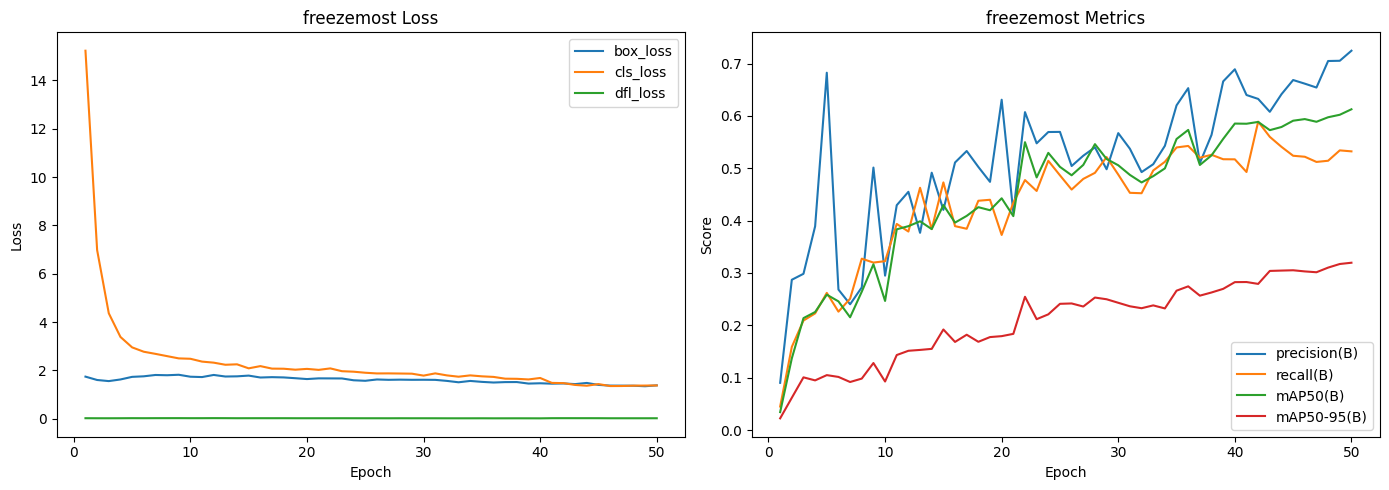

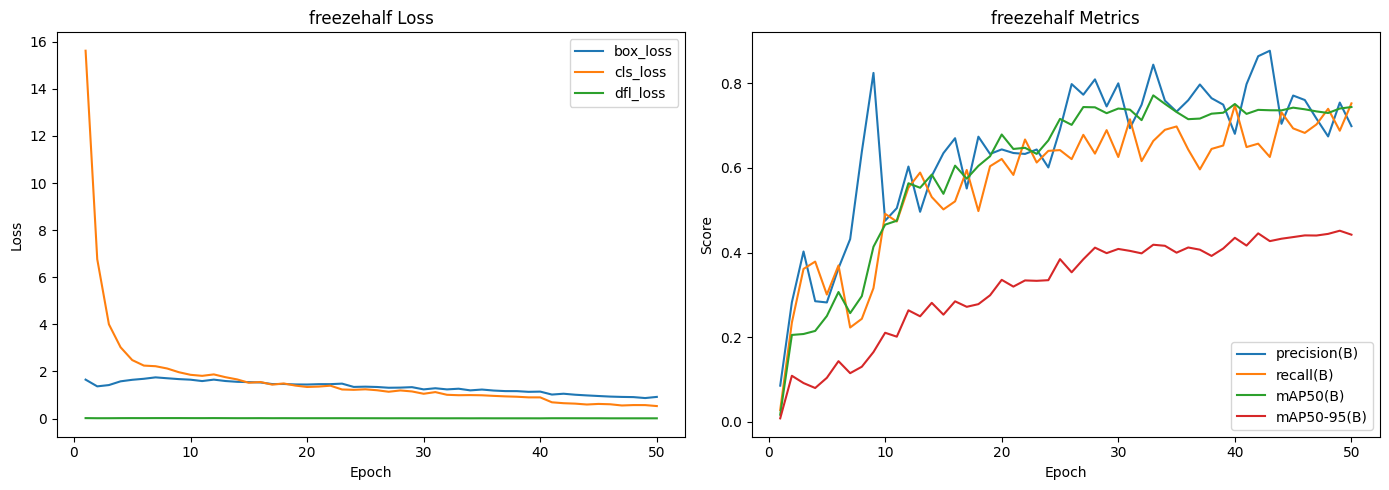

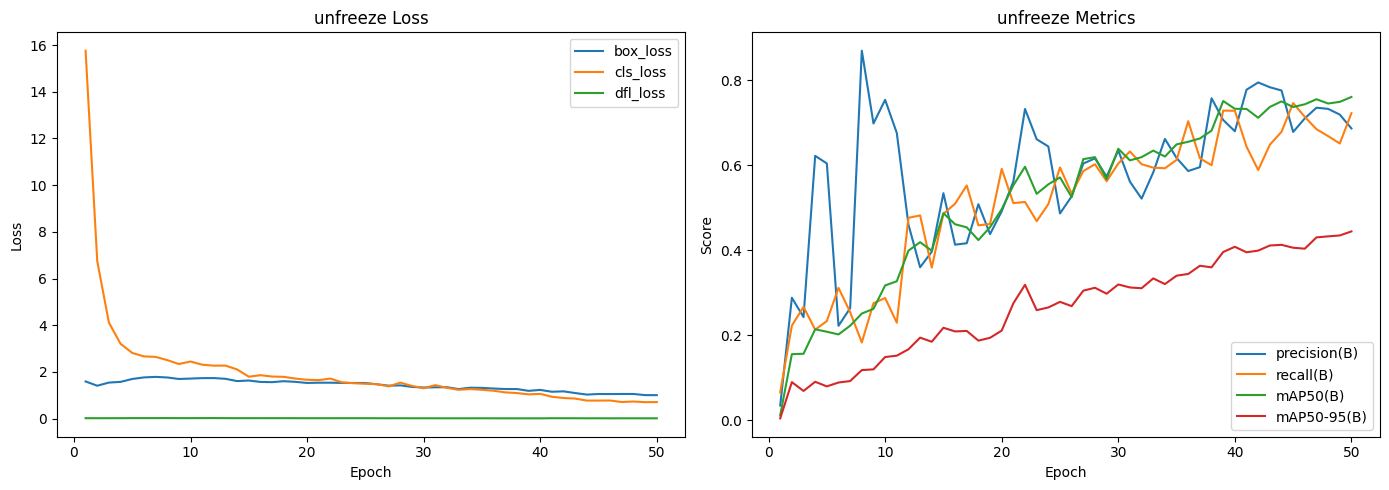

In [9]:
%matplotlib inline
runs = [
    "frozen_backbone",
    "partial_freeze_neck",
    "unfreeze"
]

for r in runs:

    plot_curves(
        f"runs/detect/road_damage/{r}/results.csv",
        r
    )

## Confusion Matrices

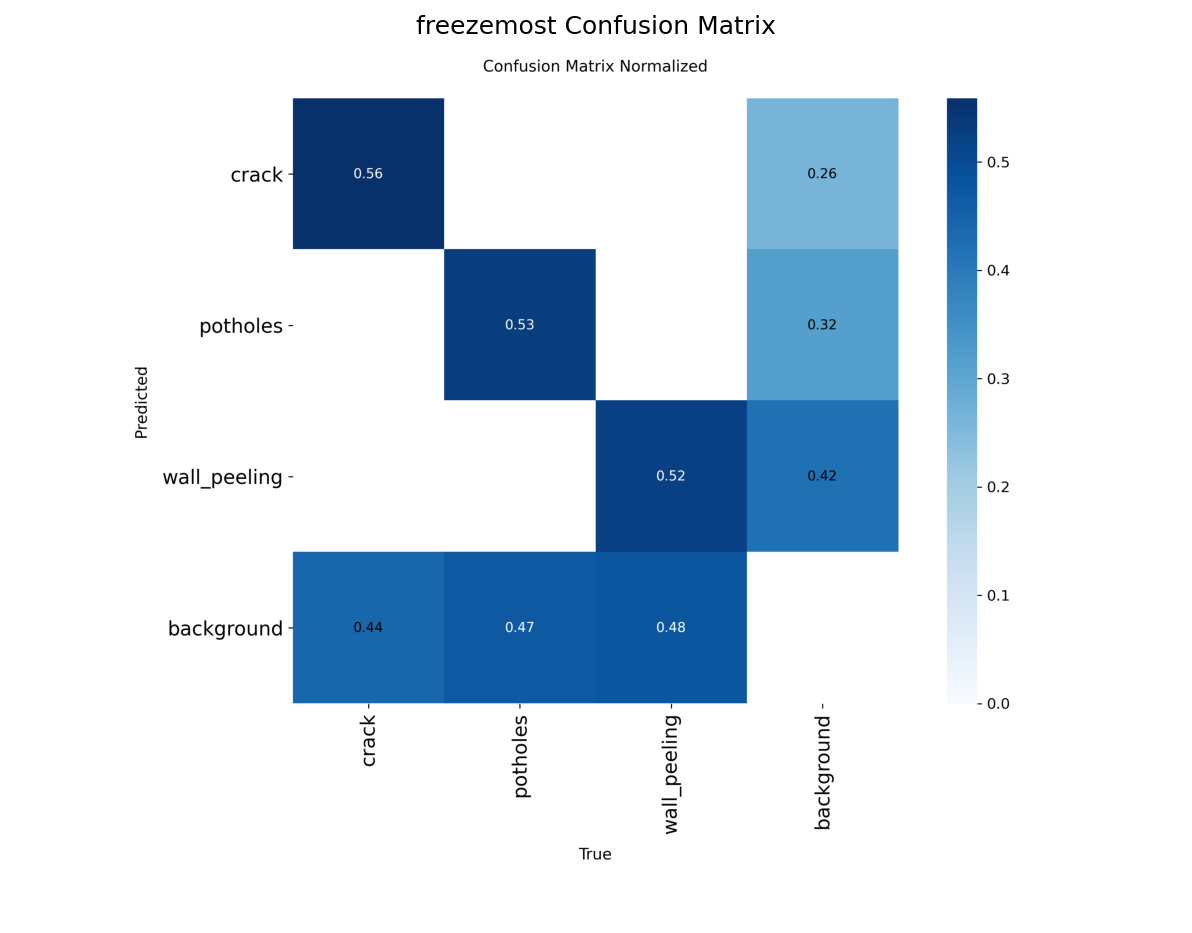

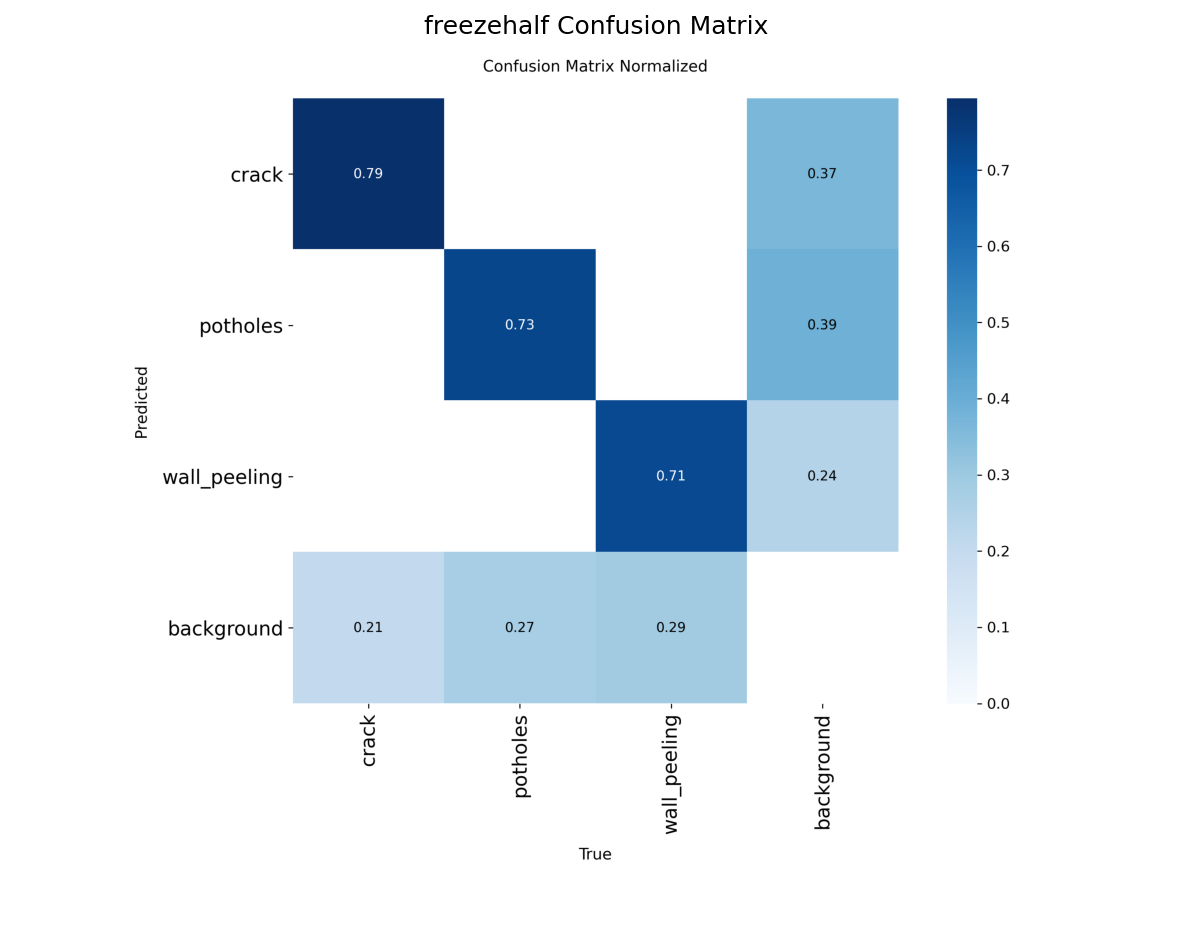

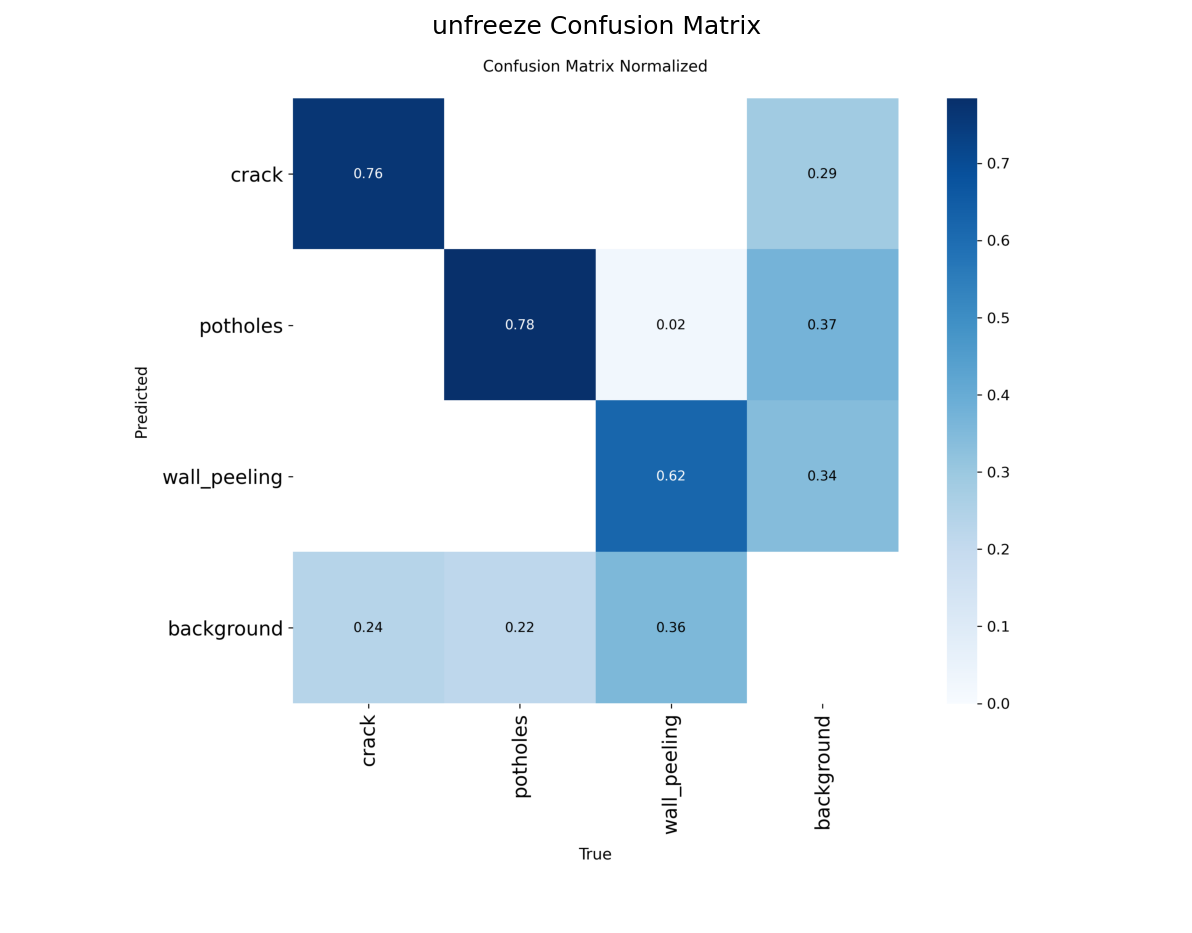

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

runs = [
    "frozen_backbone",
    "partial_freeze_neck",
    "unfrozen"
]

for r in runs:

    img_path = (
        f"runs/detect/road_damage/{r}/"
        f"confusion_matrix_normalized.png"
    )

    img = Image.open(img_path)

    plt.figure(figsize=(8,8), dpi=150)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{r} Confusion Matrix")
    plt.show()

##  Groundtruth vs Prediction

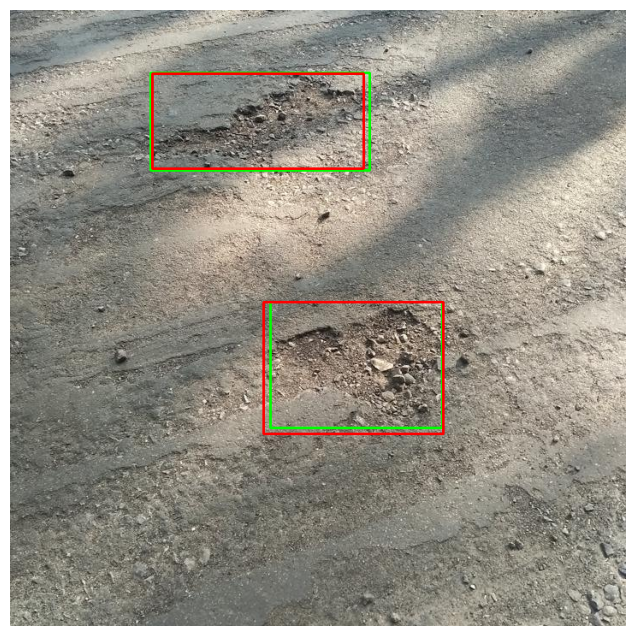

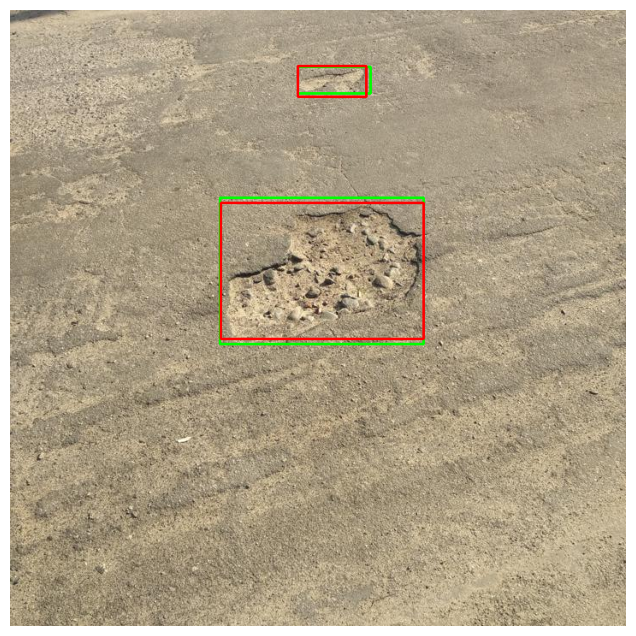

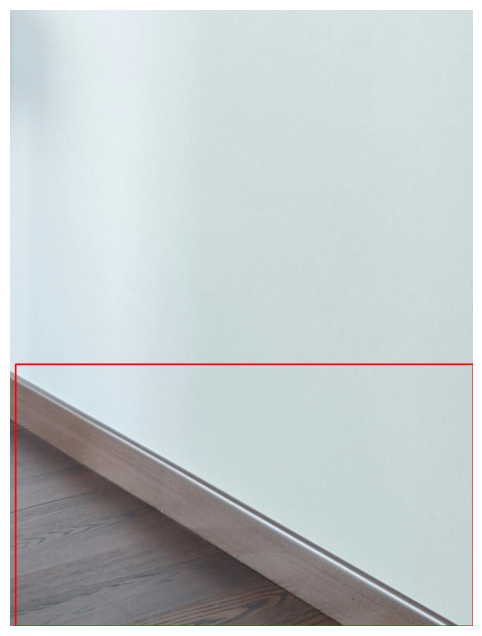

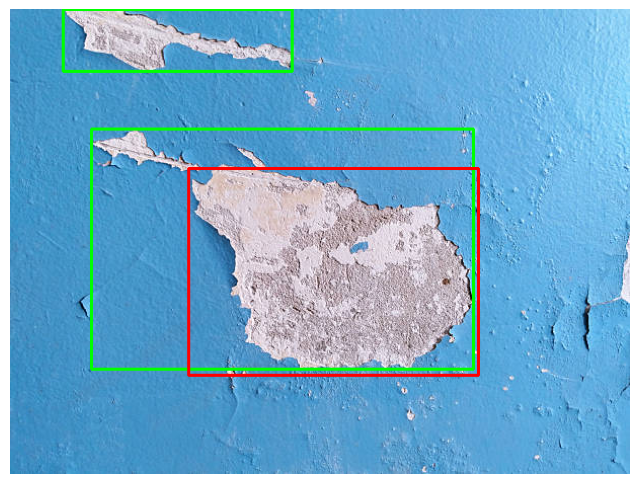

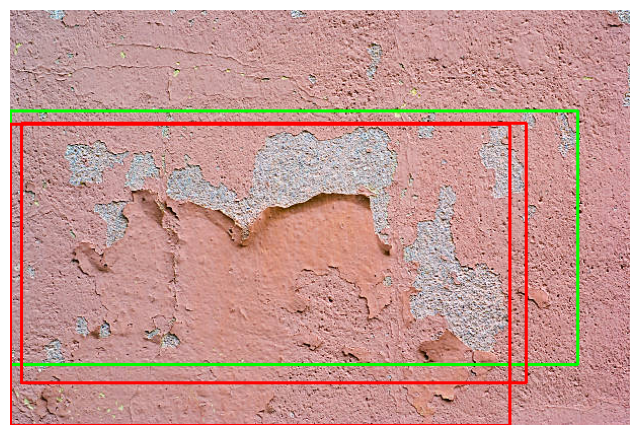

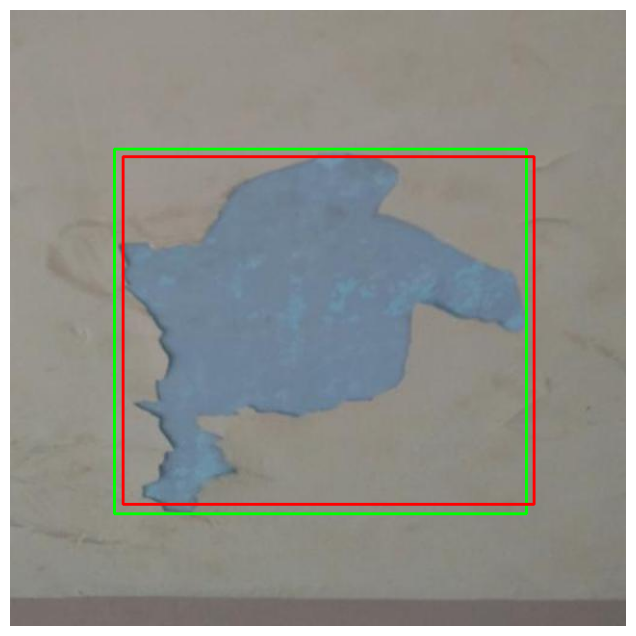

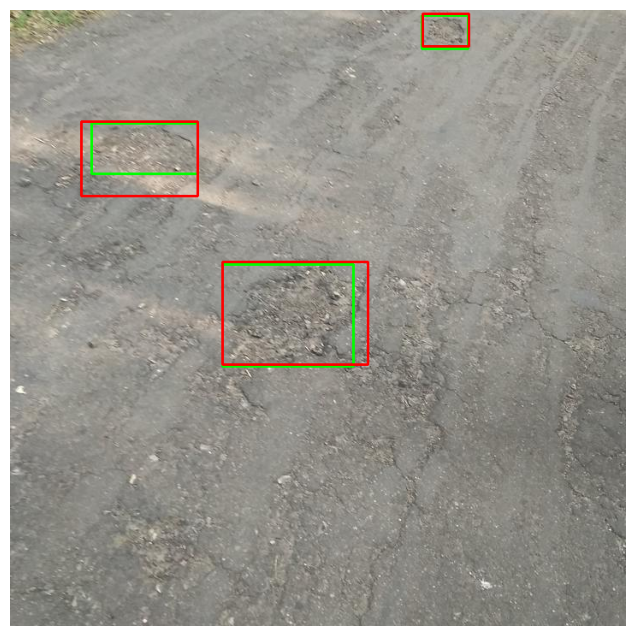

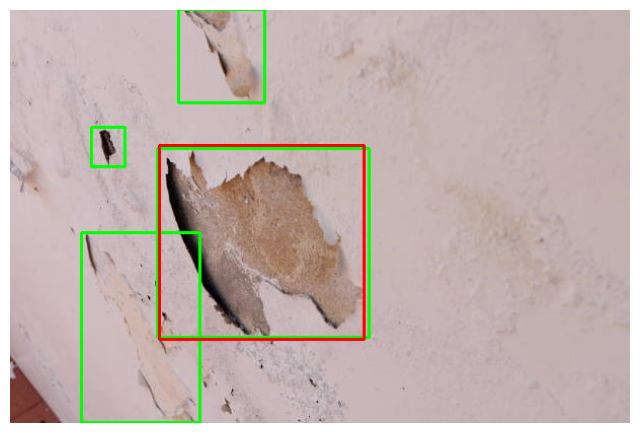

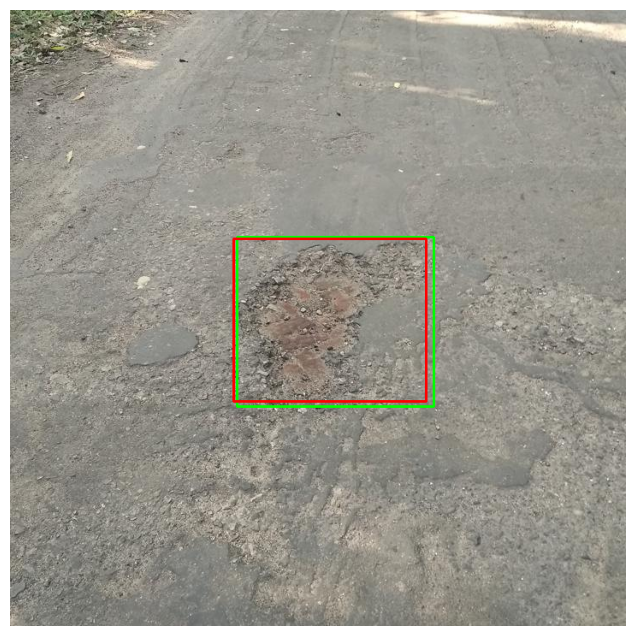

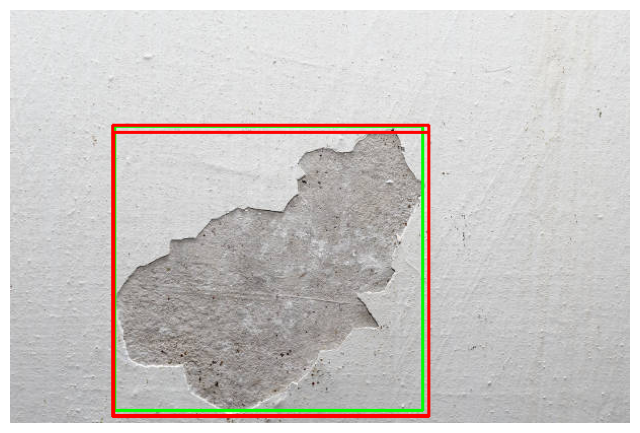

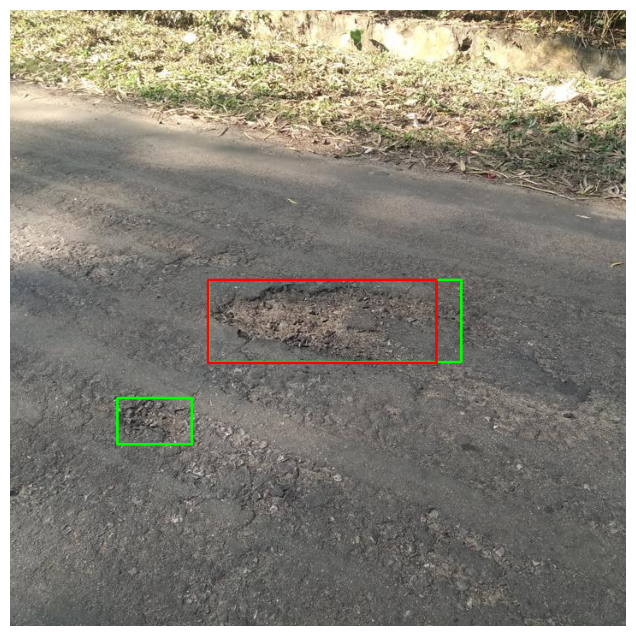

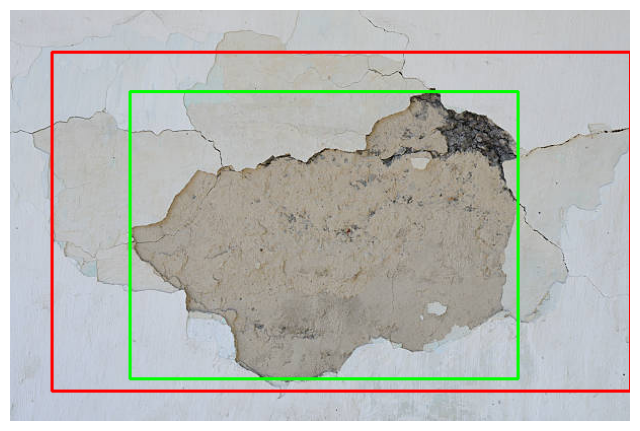

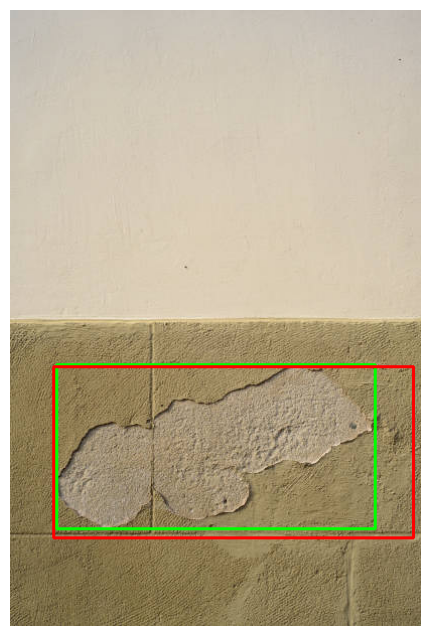

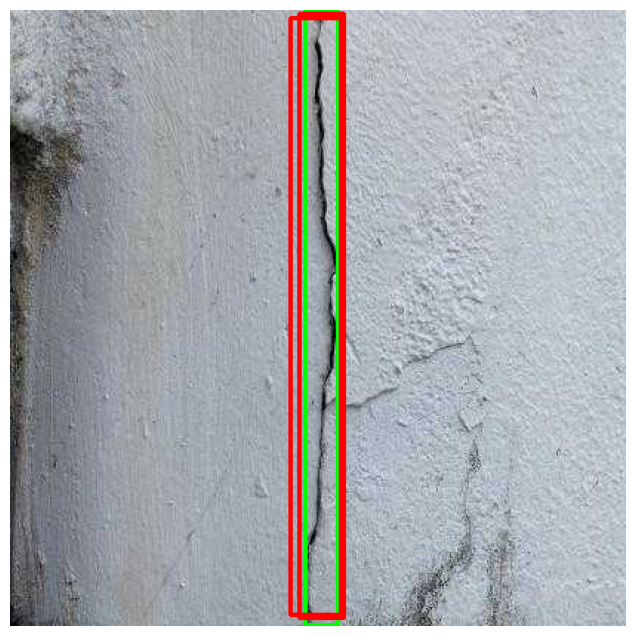

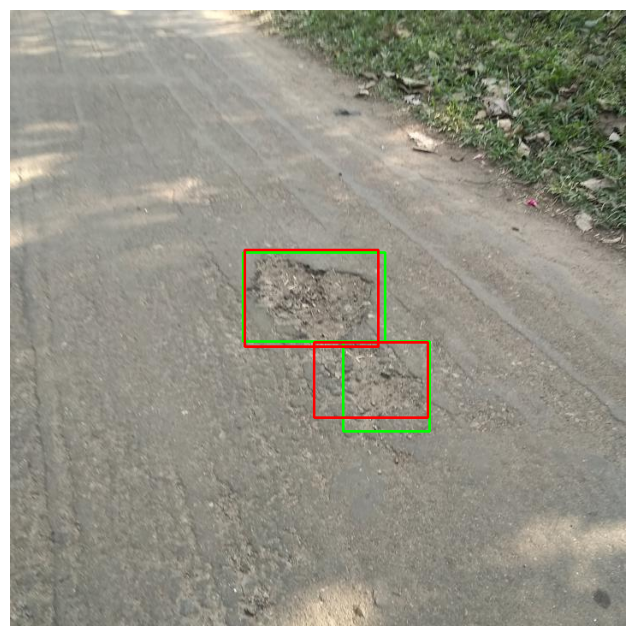

In [ ]:
from ultralytics import YOLO
import glob, os, cv2
import matplotlib.pyplot as plt

model = YOLO("runs/detect/road_damage/unfrozen/weights/best.pt")

for img_path in glob.glob("dataset/test/images/*"):

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    pred = model.predict(img_path, conf=0.25, verbose=False)[0]
    pred_boxes = pred.boxes.xyxy.cpu().numpy()

    label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

    gt_boxes = []

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h
                gt_boxes.append([x1, y1, x2, y2])

    wrong_predictions = 0
    matched_gt = set()

    # check predictions
    for p_box in pred_boxes:

        best_iou = 0
        best_gt_idx = -1

        for i, g_box in enumerate(gt_boxes):
            score = iou(g_box, p_box)
            if score > best_iou:
                best_iou = score
                best_gt_idx = i

        x1, y1, x2, y2 = map(int, p_box)

        # color rule
        if best_iou >= 0.5:
            color = (0, 255, 0)  # green = correct
            matched_gt.add(best_gt_idx)
        else:
            color = (0, 0, 255)  # red = wrong
            wrong_predictions += 1

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            f"IoU: {best_iou:.2f}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1
        )

    missed_gt = len(gt_boxes) - len(matched_gt)

    print(f"\nImage: {os.path.basename(img_path)}")
    print(f"Wrong Predictions: {wrong_predictions}")
    print(f"Missed Ground Truths: {missed_gt}")

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()